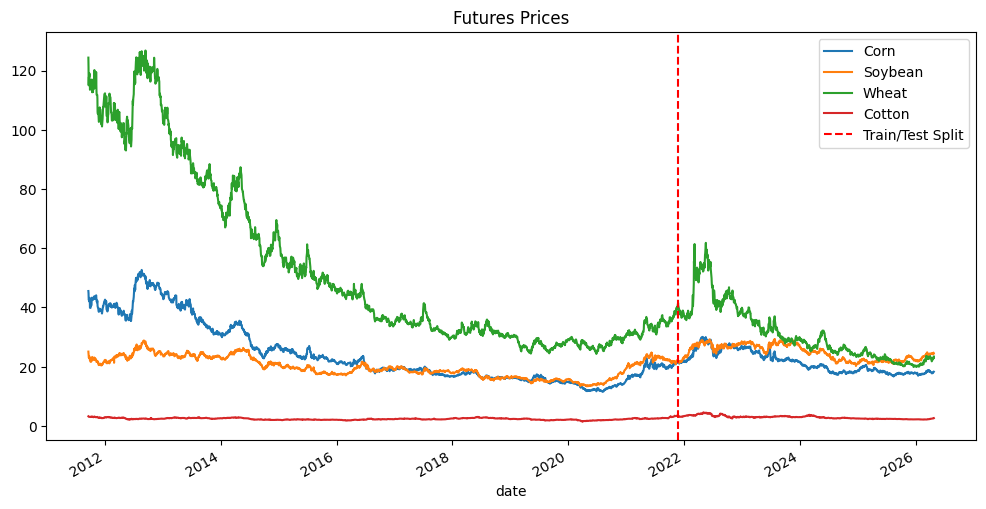

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen

df1=pd.read_csv(r'C:\Users\zezar\TilburgUniversity\Spring2026-TIC\Ensemble_Wiktor\data\merged_corn_soybean_wheat_cotton.csv', skiprows=[1], index_col=0, parse_dates=True)
corn=df1['close_corn']
soybean=df1['close_soybean']
wheat=df1['close_wheat']
cotton=df1['close_cotton']

df=pd.concat([corn, soybean, wheat, cotton], axis=1)
df.columns=['Corn', 'Soybean', 'Wheat', 'Cotton']

df_train=df.iloc[:int(len(df)*0.7)]
df_test=df.iloc[int(len(df)*0.7):]

plt.figure(figsize=(12, 6))

df['Corn'].plot(label='Corn')
df['Soybean'].plot(label='Soybean')
df['Wheat'].plot(label='Wheat')
df['Cotton'].plot(label='Cotton')

plt.axvline(x=df_train.index[-1], color='red', linestyle='--', label='Train/Test Split')
plt.title('Futures Prices')
plt.legend()
plt.show()

In [7]:
adf_corn=adfuller(df_train['Corn'])
adf_soybean=adfuller(df_train['Soybean'])
adf_wheat=adfuller(df_train['Wheat'])
adf_cotton=adfuller(df_train['Cotton'])

print(f'ADF Statistic for Corn: {adf_corn[0]}')
print(f'p-value for Corn: {adf_corn[1]}')
print(f'ADF Statistic for Soybean: {adf_soybean[0]}')
print(f'p-value for Soybean: {adf_soybean[1]}')
print(f'ADF Statistic for Wheat: {adf_wheat[0]}')
print(f'p-value for Wheat: {adf_wheat[1]}')
print(f'ADF Statistic for Cotton: {adf_cotton[0]}')
print(f'p-value for Cotton: {adf_cotton[1]}')
print(f'Critical Values: {adf_soybean[4]}')

ADF Statistic for Corn: -1.9416474883191506
p-value for Corn: 0.31272943996111335
ADF Statistic for Soybean: -1.8500507300892937
p-value for Soybean: 0.3559109696697546
ADF Statistic for Wheat: -2.2212542264301733
p-value for Wheat: 0.19862202636181386
ADF Statistic for Cotton: -2.301365976236572
p-value for Cotton: 0.17152779547395824
Critical Values: {'1%': -3.4329476085791493, '5%': -2.8626876136761292, '10%': -2.5673809185248175}


In [8]:
corn_diff=df_train['Corn'].diff().dropna()
adf_corn_diff=adfuller(corn_diff)

soybean_diff=df_train['Soybean'].diff().dropna()
adf_soybean_diff=adfuller(soybean_diff)

wheat_diff=df_train['Wheat'].diff().dropna()
adf_wheat_diff=adfuller(wheat_diff)

cotton_diff=df_train['Cotton'].diff().dropna()
adf_cotton_diff=adfuller(cotton_diff)

print(f'ADF Statistic for Corn: {adf_corn_diff[0]}')
print(f'p-value for Corn: {adf_corn_diff[1]}')
print(f'ADF Statistic for Soybean: {adf_soybean_diff[0]}')
print(f'p-value for Soybean: {adf_soybean_diff[1]}')
print(f'ADF Statistic for Wheat: {adf_wheat_diff[0]}')
print(f'p-value for Wheat: {adf_wheat_diff[1]}')
print(f'ADF Statistic for Cotton: {adf_cotton_diff[0]}')
print(f'p-value for Cotton: {adf_cotton_diff[1]}')
print(f'Critical Values: {adf_soybean_diff[4]}')

ADF Statistic for Corn: -9.171156001601226
p-value for Corn: 2.38636435725362e-15
ADF Statistic for Soybean: -56.092950108524676
p-value for Soybean: 0.0
ADF Statistic for Wheat: -11.396413869426183
p-value for Wheat: 7.838538580427442e-21
ADF Statistic for Cotton: -51.93705238817174
p-value for Cotton: 0.0
Critical Values: {'1%': -3.4329476085791493, '5%': -2.8626876136761292, '10%': -2.5673809185248175}


In [9]:
result = coint_johansen(df_train, det_order=0, k_ar_diff=1)

print('Trace Statistics:')
print(result.lr1)
print('Critical values 90%, 95%, 99%:')
print(result.cvt)

print('\nEigen Statistics:')
print(result.lr2)
print('Critical values 90%, 95%, 99%:')
print(result.cvm)

print('\nEigenvalues:')
print(result.eig)

print('\nEigenvectors:')
print(result.evec)

Trace Statistics:
[47.78175715 21.35414727  8.48468702  3.00483256]
Critical values 90%, 95%, 99%:
[[44.4929 47.8545 54.6815]
 [27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]

Eigen Statistics:
[26.42760988 12.86946025  5.47985446  3.00483256]
Critical values 90%, 95%, 99%:
[[25.1236 27.5858 32.7172]
 [18.8928 21.1314 25.865 ]
 [12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]

Eigenvalues:
[0.01043235 0.00509391 0.00217218 0.00119168]

Eigenvectors:
[[ 6.76437166e-01  3.04093442e-01 -3.83718935e-03 -9.97629375e-02]
 [-1.22725607e-01 -5.47321532e-01 -2.70188913e-01  1.39301467e-01]
 [-2.25656548e-01 -5.38831476e-02  6.67841945e-04 -6.41801200e-03]
 [-8.60134947e-01  2.43572031e+00 -3.50002014e-01  2.77488660e+00]]


In [11]:
hedge_ratios = result.evec[:, 0]
print(f'Corn:    {hedge_ratios[0]:.4f}')
print(f'Soybean: {hedge_ratios[1]:.4f}')
print(f'Wheat:   {hedge_ratios[2]:.4f}')
print(f'Cotton:  {hedge_ratios[3]:.4f}')

Corn:    0.6764
Soybean: -0.1227
Wheat:   -0.2257
Cotton:  -0.8601


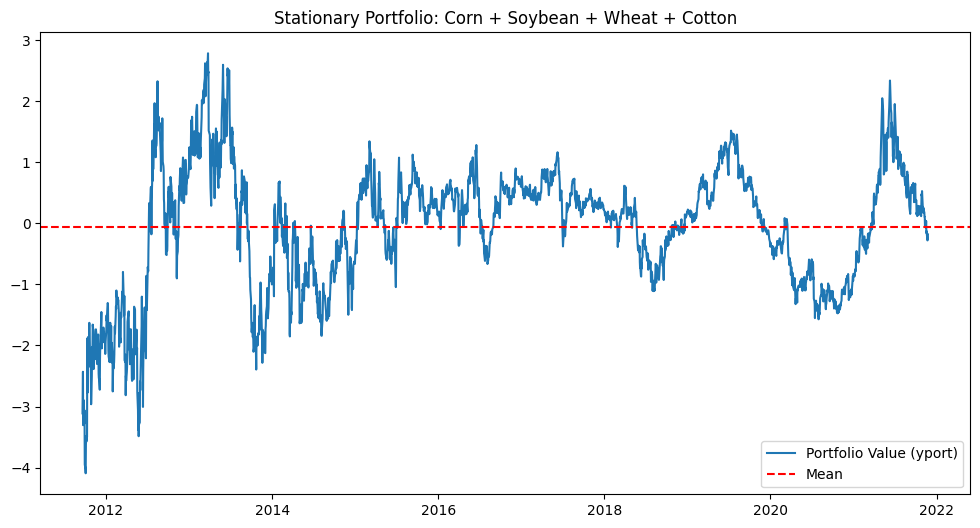


ADF Statistic: -4.8797
p-value: 0.0000
Critical Values: {'1%': -3.4329476085791493, '5%': -2.8626876136761292, '10%': -2.5673809185248175}


In [12]:
yport = (df_train * hedge_ratios).sum(axis=1)

plt.figure(figsize=(12, 6))
plt.plot(yport.index, yport.values, label='Portfolio Value (yport)')
plt.axhline(yport.mean(), color='red', linestyle='--', label='Mean')
plt.title('Stationary Portfolio: Corn + Soybean + Wheat + Cotton')
plt.legend()
plt.show()

adf_yport = adfuller(yport, maxlag=1, autolag=None)
print(f'\nADF Statistic: {adf_yport[0]:.4f}')
print(f'p-value: {adf_yport[1]:.4f}')
print(f'Critical Values: {adf_yport[4]}')

In [15]:
yport_diff = yport.diff().dropna()
yport_lagged = yport.shift(1).dropna()
yport_lagged = sm.add_constant(yport_lagged)
model_hl = sm.OLS(yport_diff, yport_lagged)
result_hl = model_hl.fit()
lambda_val = result_hl.params.iloc[1]  
half_life = -np.log(2) / lambda_val
print(f'Half life: {half_life:.1f} days')

Half life: 33.4 days


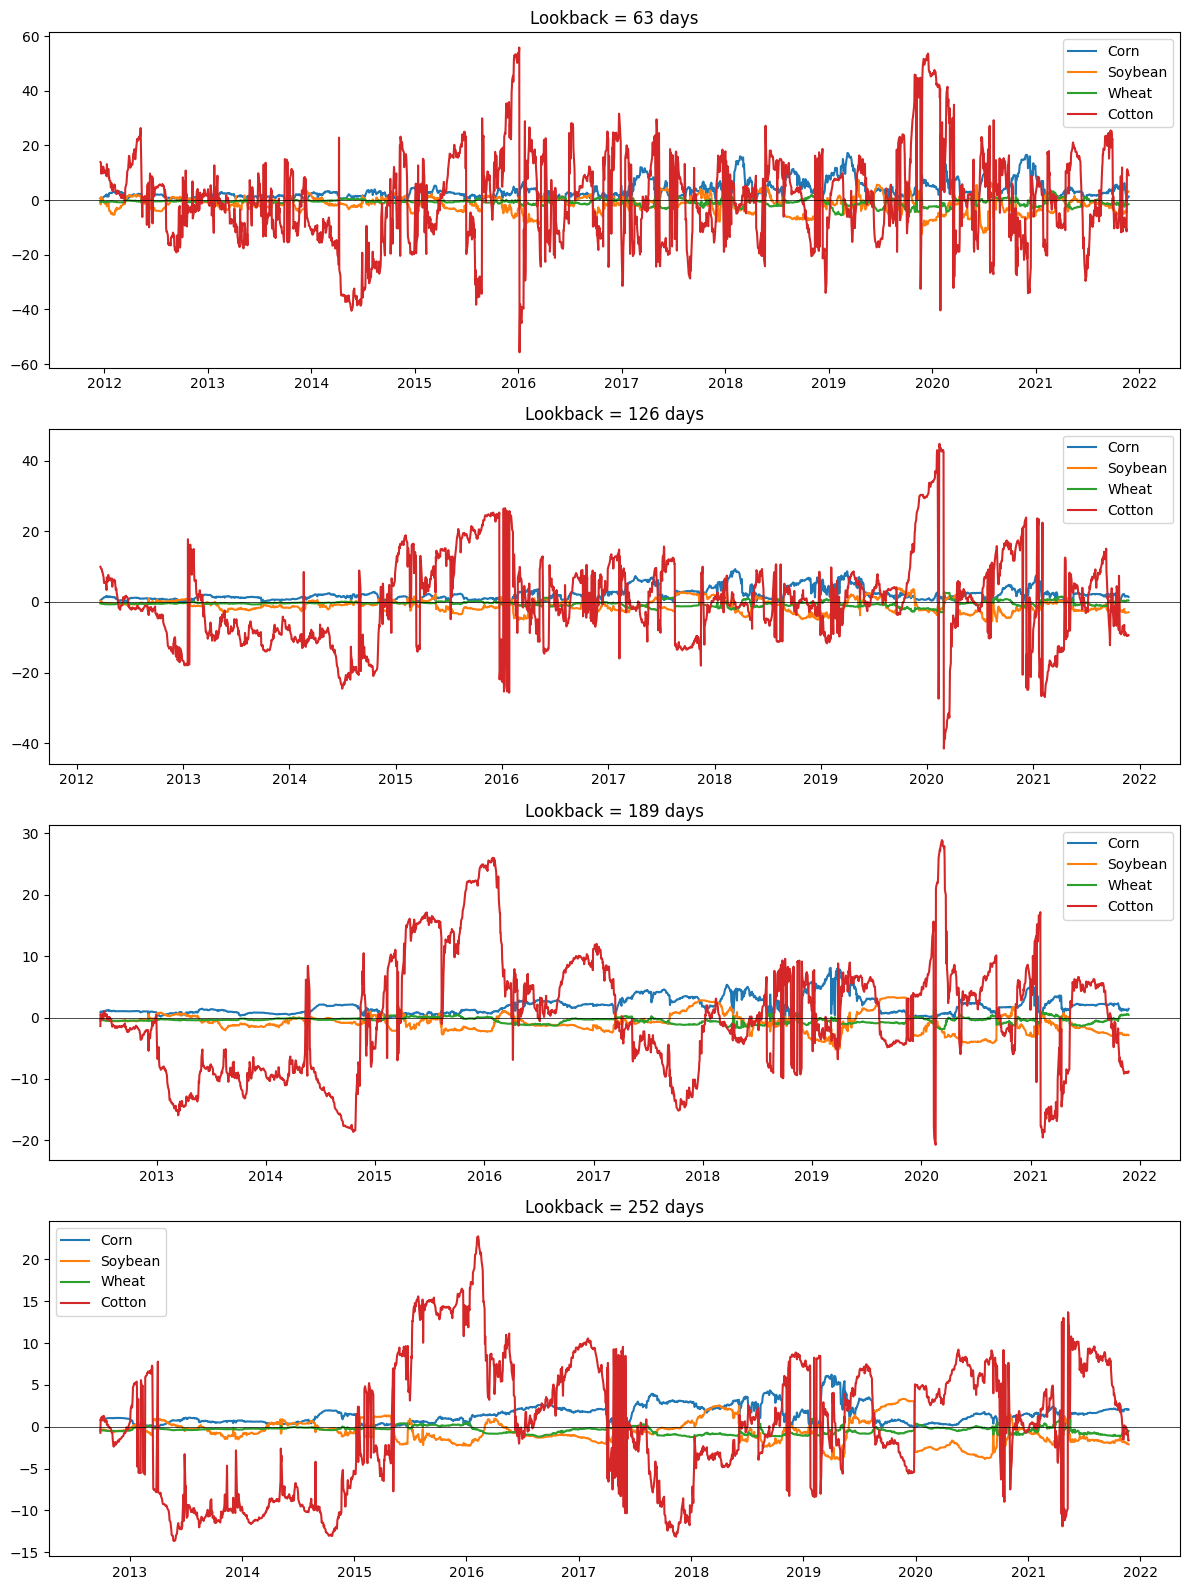

In [18]:
def rolling_eigenvectors(df_train, lookback):
    n_assets = df_train.shape[1]
    eigenvectors = np.full((len(df_train), n_assets), np.nan)
    
    for i in range(lookback, len(df_train)):
        window = df_train.iloc[i-lookback:i]
        try:
            result = coint_johansen(window, det_order=0, k_ar_diff=1)
            eigenvectors[i] = result.evec[:, 0]
        except:
            pass
    
    return pd.DataFrame(eigenvectors, index=df_train.index, columns=df_train.columns)

fig, axes = plt.subplots(4, 1, figsize=(12, 16))
for ax, lb in zip(axes, [63, 126, 189, 252]):
    eigvec = rolling_eigenvectors(df_train, lb)
    for col in eigvec.columns:
        ax.plot(eigvec.index, eigvec[col], label=col)
    ax.set_title(f'Lookback = {lb} days')
    ax.legend()
    ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

{1.0: 1.5628772687619854, 1.5: 1.499871995954633, 2.0: 1.2050514749485686, 2.5: 0.8974037533470566, 3.0: 0.434593210129421}
Best threshold: 1.0


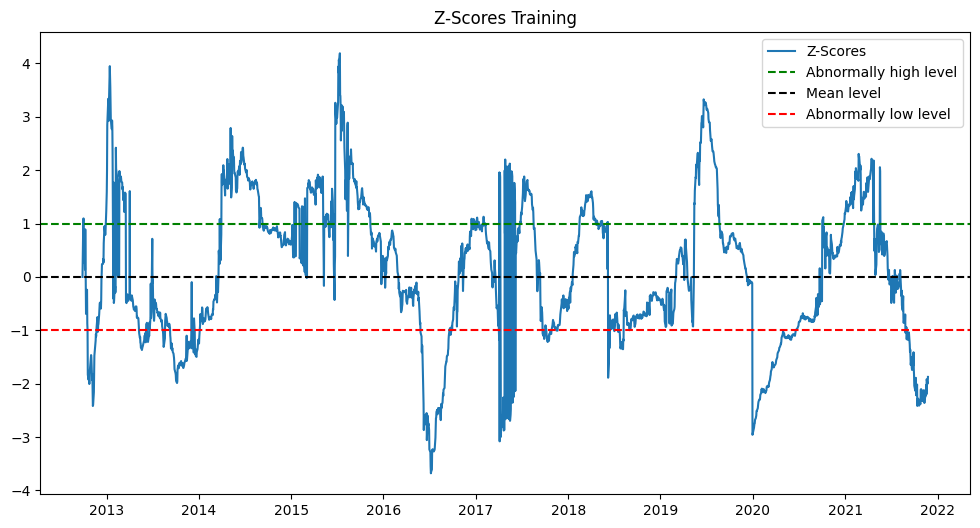

In [21]:
LOOKBACK = 252
hedge_train = np.full((len(df_train), 4), np.nan)
rolling_spread = np.full(len(df_train), np.nan)

for i in range(LOOKBACK, len(df_train)):
    window = df_train.iloc[i-LOOKBACK:i]
    result_window = coint_johansen(window, det_order=0, k_ar_diff=1)
    hedge_train[i] = result_window.evec[:, 0]
    rolling_spread[i] = (df_train.iloc[i].values * result_window.evec[:, 0]).sum()

rolling_spread_series = pd.Series(rolling_spread, index=df_train.index)

z_scores = np.full(len(rolling_spread_series), np.nan)
for i in range(LOOKBACK, len(rolling_spread_series)):
    window_rolling_spread = rolling_spread_series.iloc[i-LOOKBACK:i]
    mean_rolling_spread = np.mean(window_rolling_spread)
    std_rolling_spread = np.std(window_rolling_spread)
    if std_rolling_spread == 0:
        z_scores[i] = 0
    else:
        z_scores[i] = (window_rolling_spread.iloc[-1] - mean_rolling_spread) / std_rolling_spread

thresholds = [1.0, 1.5, 2.0, 2.5, 3.0]
results = {}

for entry in thresholds:
    positions = np.zeros(len(z_scores))
    position = 0
    for j in range(len(z_scores)):
        if np.isnan(z_scores[j]):
            position = 0
        elif z_scores[j] >= entry:
            position = -1
        elif z_scores[j] <= -entry:
            position = 1
        elif position == 1 and z_scores[j] >= 0:
            position = 0
        elif position == -1 and z_scores[j] <= 0:
            position = 0
        positions[j] = position
    
    spread_changes = rolling_spread_series.diff()
    pnl = positions * spread_changes
    sharpe_ratio = np.mean(pnl) / np.std(pnl) * np.sqrt(252)
    results[entry] = sharpe_ratio

best_threshold = max(results, key=results.get)
print(results)
print(f'Best threshold: {best_threshold}')

plt.figure(figsize=(12,6))
plt.plot(df_train.index, z_scores, label='Z-Scores')
plt.axhline(y=best_threshold, color='green', linestyle='--', label='Abnormally high level')
plt.axhline(y=0, color='black', linestyle='--', label='Mean level')
plt.axhline(y=-best_threshold, color='red', linestyle='--', label='Abnormally low level')
plt.title('Z-Scores Training')
plt.legend()
plt.show()

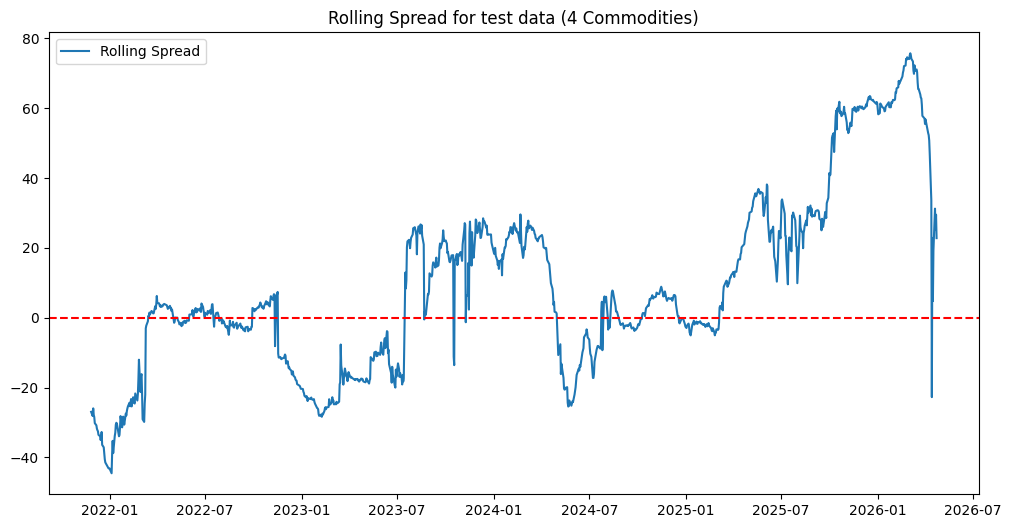

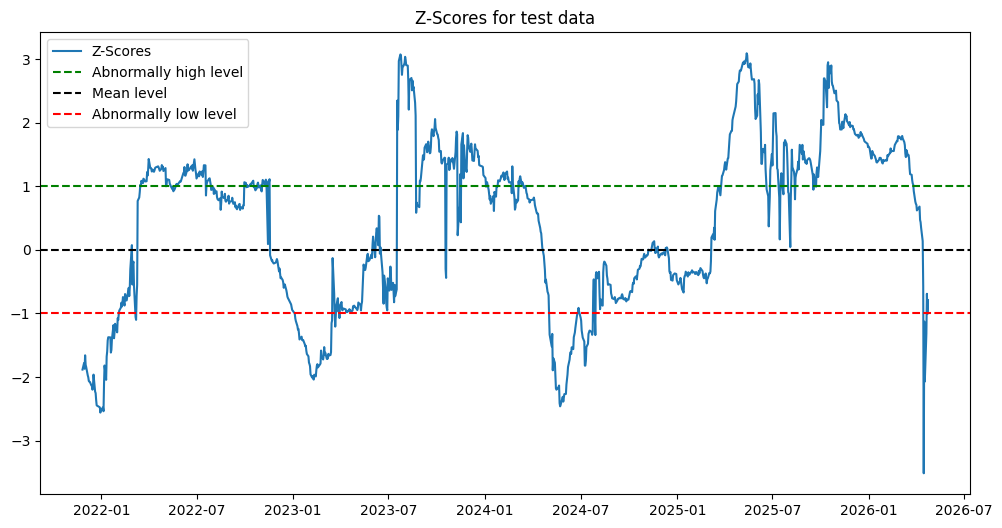

In [22]:
hedge_final = np.full((len(df), 4), np.nan)
spread_final = np.full(len(df), np.nan)

for i in range(LOOKBACK, len(df)):
    window = df.iloc[i-LOOKBACK:i]
    result_window = coint_johansen(window, det_order=0, k_ar_diff=1)
    hedge_final[i] = result_window.evec[:, 0]
    spread_final[i] = (df.iloc[i].values * result_window.evec[:, 0]).sum()

spread_final_series = pd.Series(spread_final, index=df.index)
hedge_final_df = pd.DataFrame(hedge_final, index=df.index, columns=['Corn', 'Soybean', 'Wheat', 'Cotton'])

z_scores_final = np.full(len(spread_final_series), np.nan)
for j in range(LOOKBACK, len(df)):
    window_spread_final = spread_final_series.iloc[j-LOOKBACK:j]
    mean_spread_final = np.mean(window_spread_final)
    std_spread_final = np.std(window_spread_final)
    if std_spread_final == 0:
        z_scores_final[j] = 0
    else:
        z_scores_final[j] = (window_spread_final.iloc[-1] - mean_spread_final) / std_spread_final

z_scores_final_series = pd.Series(z_scores_final, index=df.index)

z_scores_test = z_scores_final_series[df.index >= df_test.index[0]]
spread_test = spread_final_series[df.index >= df_test.index[0]]

plt.figure(figsize=(12,6))
plt.plot(df_test.index, spread_test, label='Rolling Spread')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Rolling Spread for test data (4 Commodities)')
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df_test.index, z_scores_test, label='Z-Scores')
plt.axhline(y=best_threshold, color='green', linestyle='--', label='Abnormally high level')
plt.axhline(y=0, color='black', linestyle='--', label='Mean level')
plt.axhline(y=-best_threshold, color='red', linestyle='--', label='Abnormally low level')
plt.title('Z-Scores for test data')
plt.legend()
plt.show()

Sharpe Ratio:   -0.007
Total Return:   -1.74%
Max Drawdown:   -17.45%
Total P&L:      -0.89


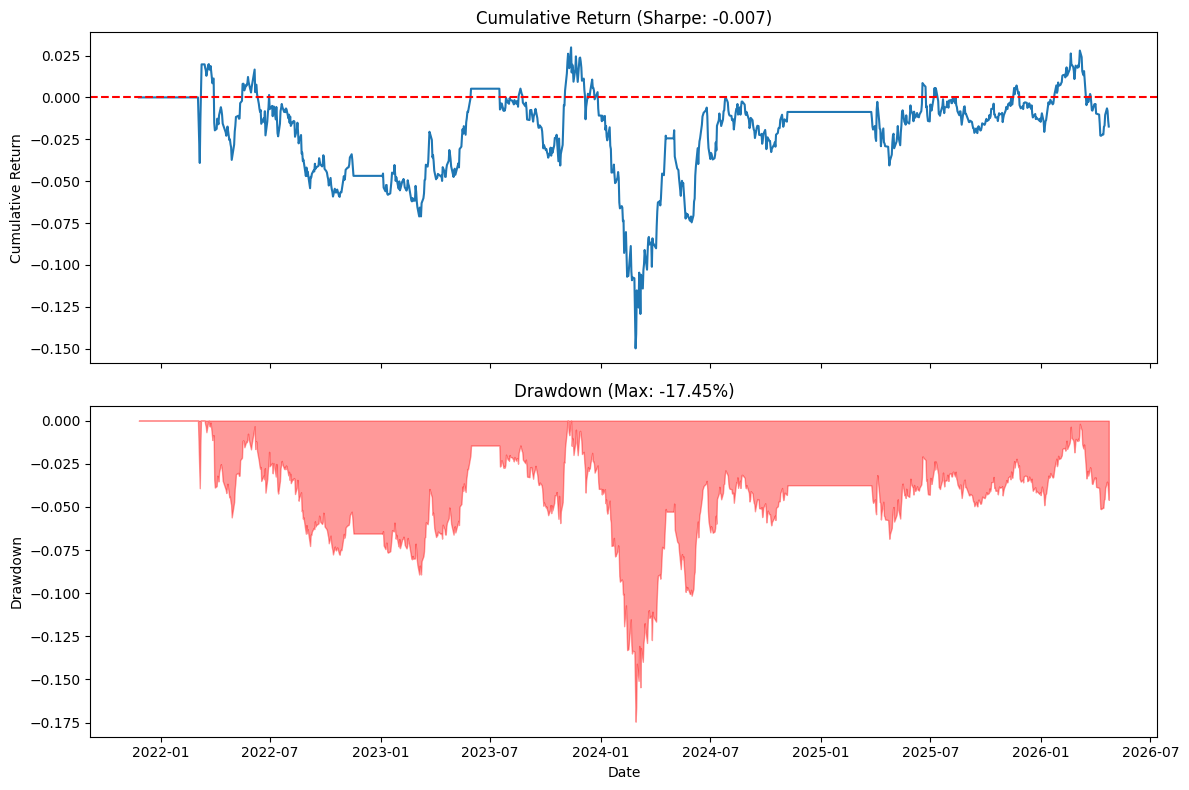

In [24]:
THRESHOLD = best_threshold

positions_final = np.zeros(len(z_scores_test))
position_final = 0
for i in range(len(z_scores_test)):
    if np.isnan(z_scores_test.iloc[i]):
        position_final = 0
    elif z_scores_test.iloc[i] >= THRESHOLD:
        position_final = -1
    elif z_scores_test.iloc[i] <= -THRESHOLD:
        position_final = 1
    elif position_final == 1 and z_scores_test.iloc[i] >= 0:
        position_final = 0
    elif position_final == -1 and z_scores_test.iloc[i] <= 0:
        position_final = 0
    positions_final[i] = position_final

split = int(len(df) * 0.7)
hedge_test = hedge_final[split:]
corn_test = df_test['Corn'].values
soy_test = df_test['Soybean'].values
wheat_test = df_test['Wheat'].values
cotton_test = df_test['Cotton'].values
delta_corn = df_test['Corn'].diff().values
delta_soy = df_test['Soybean'].diff().values
delta_wheat = df_test['Wheat'].diff().values
delta_cotton =  df_test['Cotton'].diff().values

pnl_fixed = np.zeros(len(positions_final))
returns = np.zeros(len(positions_final))
hedge_entry = None
capital_entry = np.nan

for i in range(1, len(positions_final)):
    prev_pos = positions_final[i-1]
    curr_pos = positions_final[i]
    
    if prev_pos == 0 and curr_pos != 0:
        hedge_entry = hedge_test[i]
        capital_entry = (abs(hedge_entry[0]) * corn_test[i-1] + abs(hedge_entry[1]) * soy_test[i-1] + abs(hedge_entry[2]) * wheat_test[i-1] + abs(hedge_entry[3]) * cotton_test[i-1])
    
    if curr_pos != 0 and hedge_entry is not None:
        pnl_fixed[i] = curr_pos * (hedge_entry[0] * delta_corn[i] + hedge_entry[1] * delta_soy[i] + hedge_entry[2] * delta_wheat[i] + hedge_entry[3]*delta_cotton[i])
        returns[i] = pnl_fixed[i] / capital_entry
    else:
        pnl_fixed[i] = 0.0
        returns[i] = 0.0
    
    if curr_pos == 0:
        hedge_entry = None
        capital_entry = np.nan

returns = pd.Series(returns, index=df_test.index)
pnl_fixed = pd.Series(pnl_fixed, index=df_test.index)

sharpe = np.mean(returns) / np.std(returns) * np.sqrt(252) if np.std(returns) > 0 else 0
cum_ret = (1 + returns).cumprod() - 1
total_ret = cum_ret.iloc[-1]
rolling_max = (1 + returns).cumprod().cummax()
drawdown = (1 + returns).cumprod() / rolling_max - 1
max_dd = drawdown.min()

print(f'Sharpe Ratio:   {sharpe:.3f}')
print(f'Total Return:   {total_ret:.2%}')
print(f'Max Drawdown:   {max_dd:.2%}')
print(f'Total P&L:      {pnl_fixed.sum():.2f}')

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(cum_ret.index, cum_ret.values)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title(f'Cumulative Return (Sharpe: {sharpe:.3f})')
axes[0].set_ylabel('Cumulative Return')

axes[1].fill_between(drawdown.index, drawdown.values, 0, alpha=0.4, color='red')
axes[1].set_title(f'Drawdown (Max: {max_dd:.2%})')
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()